<font color='tomato'><font color="#CC3D3D"><p>
# Baseline Code (v2.0)

- `SHAP`을 이용한 Feature selection 코드 추가
- `KMeansFeaturizer`을 이용한 Feature generation 코드 추가

- shap을 통해 피처를 selection하면 feature_importance 쓰는거 보다 정확하니까 효과를 볼수 있음 근데 지금은 피처가 20개 밖에 없으니까 많이 만들어보자
- KMeansFeaturizer 피처를 자동으로 만들어줌 근데 이거 안돌아가던데 ㅋㅋ

##### Imports & Global Setting

In [1]:
import pandas as pd
import numpy as np
import os
import random
import pickle
import gzip
import gc
import re
import warnings; warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pylab as plt
from matplotlib import font_manager, rc
from tqdm import tqdm, tqdm_notebook
%matplotlib inline

from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score




import shap # v2.0부터 추가


In [2]:
VERSION = 2.0
SHAP_THRESHOLD = 0.001  # v2.0부터 추가

### Data Loading

In [3]:
train = pd.read_csv('../../data/train.csv', encoding='cp949')
test = pd.read_csv('../../data/test.csv', encoding='cp949')

### 데이터 설명
- **패널(Panel) 데이터**
  - userID: 패널 ID
  - BIRTH: 생일(연도)
  - GENDER: 1(남자) 2(여자)
  - REGION: 거주지역
  - TYPE: 패널 구분
  - SQ1 ~ DQ7: 패널 가입 시 설문조사 데이터로 각 필드에 대한 [상세설명](https://docs.google.com/spreadsheets/d/1pY6MYTSkyHrGLmMTU8tX_xlD8fPut6Ob/edit?usp=sharing&ouid=107121563618260277687&rtpof=true&sd=true) 참조
- **설문(Survey) 데이터**
  - surveyID: 설문 ID
  - TITLE: 설문 제목
  - IR: 난이도(응답가능성, 100이 최고)
  - LOI: 설문하는데 걸리는 시간 (분단위)
  - CATEGORIES: 설문 분류
  - CPI: 패널 응답 리워드 포인트(1P~)
- **응답(Response) 데이터**
  - STATUS: 응답여부 (Target)
  - (test 데이터의) ID: submission을 식별하기 위한 ID로 사용

- SQ1 ~ DQ7 결측치도 많고 이게 응답률에 의미가 있을까?

- IR 숫자가 높을 수록 난이도 높
- LOI -시간
- CPI -리워드

* 설문응답률 설문데이터관련 피처가 중요할 것같음
* 테스트에서 ID는 인덱스의 의미
* 결측치 개많!
* 30%이하피쳐는 안썼음


### Data Preprocessing

##### Clean data & derive features

In [4]:
train

,userID,surveyID,BIRTH,GENDER,REGION,TYPE,SQ1,SQ2,SQ3,SQ4,...,DQ4,DQ5,DQ6,DQ7,TITLE,IR,LOI,CATEGORIES,CPI,STATUS
0,p00000,s04673,1976.0,1.0,2.0,D,1.0,1976.0,1.0,"1,",...,NaN,NaN,NaN,NaN,해외-일반인의견조사(G-925574),100,13,NaN,715.0,1
1,p00000,s04675,1976.0,1.0,2.0,D,1.0,1976.0,1.0,"1,",...,NaN,NaN,NaN,NaN,해외-일반인의견조사(G-926698),100,10,NaN,550.0,1
2,p00000,s04683,1976.0,1.0,2.0,D,1.0,1976.0,1.0,"1,",...,NaN,NaN,NaN,NaN,해외---일반인-의견-조사-(DR-1379333)S,100,12,NaN,480.0,1
3,p00000,s04684,1976.0,1.0,2.0,D,1.0,1976.0,1.0,"1,",...,NaN,NaN,NaN,NaN,해외---일반인-의견-조사-(DR-8609533)S,100,12,NaN,480.0,1
4,p00000,s04686,1976.0,1.0,2.0,D,1.0,1976.0,1.0,"1,",...,NaN,NaN,NaN,NaN,해외---일반인-의견-조사-(DR-9958375)L,100,15,NaN,600.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813645,p16050,s05667,1983.0,1.0,16.0,D,1.0,1983.0,6.0,"4,",...,NaN,NaN,NaN,NaN,소비자의견조사(JY-PAS),30,9,"Smoking, Tobacco,Shopping, Retail",550.0,1
813646,p16050,s05802,1983.0,1.0,16.0,D,1.0,1983.0,6.0,"4,",...,NaN,NaN,NaN,NaN,소비자의견조사(JM-WR),5,15,"Shopping, Retail,Beverages - non alcoholic,Bev...",825.0,1
813647,p16050,s05838,1983.0,1.0,16.0,D,1.0,1983.0,6.0,"4,",...,NaN,NaN,NaN,NaN,소비자의견조사(JM-KB),50,15,"Finance, Banking",825.0,1
813648,p16050,s05899,1983.0,1.0,16.0,D,1.0,1983.0,6.0,"4,",...,NaN,NaN,NaN,NaN,일반인의견조사(GH-5),80,5,etc,275.0,1


In [5]:
# 결측값 비율이 30% 이하인 column만 사용
features = []
for f in train.columns:
    if train[f].isnull().sum()/train.shape[0] <= 0.3:
        print(f, '\t', train[f].nunique(), '\t', train[f].isnull().sum()/train.shape[0])
        features.append(f)

userID 	 15155 	 0.0
surveyID 	 1293 	 0.0
BIRTH 	 76 	 0.0
GENDER 	 2 	 0.0
REGION 	 17 	 0.0
TYPE 	 3 	 0.0
SQ1 	 2 	 0.0009770785964481042
SQ2 	 82 	 0.0014293615190806859
SQ3 	 47 	 0.09023044306520002
SQ4 	 52 	 0.09058931973207153
SQ5 	 273 	 0.14450930989983407
SQ6 	 30 	 0.14490751551649972
SQ7 	 1234 	 0.1802556381736619
SQ8 	 1774 	 0.1831610643397038
A1 	 2768 	 0.2083279051189086
B1 	 131 	 0.21447796964296686
B2 	 120 	 0.2426792847047256
B3 	 110 	 0.24790757696798377
B4 	 715 	 0.2602888219750507
B5 	 669 	 0.26743317151109197
TITLE 	 1286 	 0.0
IR 	 42 	 0.0
LOI 	 26 	 0.0
CPI 	 43 	 0.0
STATUS 	 2 	 0.0


In [6]:
# 불필요한 ID들은 제외. SQ1 ~ SQ3는 GENDER, BIRTH, REGION과 중복이어서 제외!

features.remove('userID')
features.remove('surveyID')
features.remove('STATUS')
features.remove('SQ1')
features.remove('SQ2')
features.remove('SQ3')

In [7]:
# 거주 주택 형태: 1/2/3/4/5/6/97이 정상값
train.SQ4.value_counts()

SQ4
1,                           226496
1                            156663
3                             97597
1                             44106
2                             42385
3,                            34304
4                             32486
4,                            27938
2,                            25578
5                             11522
5,                            10608
2                              7375
4                              4984
3                              4592
5                              3281
6,                             3005
6                              1880
6                               853
7                               434
97,원룸                           413
97,단독주택                         395
97,맑음                           353
97,기숙사                          224
97                              218
97                              184
97,폭염                           179
97,흐림                           165
7                       

In [8]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,']:
        return int(x[0])
    else:
        return 99

train.SQ4 = train.SQ4.apply(handle_profile)
test.SQ4 = test.SQ4.apply(handle_profile)

In [9]:
# 최종학력: 1/2/3/4 정상값
train.SQ5.value_counts()[:20]

SQ5
3.0                 261915
1.0                 117143
3                    82671
4.0                  45968
1                    44135
2.0                  43504
2                    28922
3.0                  20543
4                    11984
99.0                  7539
1.0                   4391
4.0                   3075
2.0                   1567
8.0                   1037
16.0                   760
1,2,3,5                493
12,2,9                 491
1,13,2,3,4,5,8,9       350
1,13,18,2,4,5,9        331
10.0                   316
Name: count, dtype: int64

In [10]:
def handle_profile(x):
    if x in ['1', '2', '3', '4']:
        return int(x)
    elif x in ['1.0', '2.0', '3.0', '4.0']:
        return int(x[0])
    else:
        return 99

train.SQ5 = train.SQ5.apply(handle_profile)
test.SQ5 = test.SQ5.apply(handle_profile)

In [11]:
# 결혼여부: 1/2/97 정상값
train.SQ6.value_counts()

SQ6
2                                         186233
1                                         151556
2,                                        112287
1,                                         68424
4                                          58570
3                                          44955
2                                          25121
5                                          17839
1                                          17779
97                                          4010
3                                           2513
4                                           2069
97,이혼                                       1106
97                                           991
99                                           756
2,21,5,8,9                                   394
5                                            387
97,사별                                        270
99                                           237
97,별거                                         72
10              

In [12]:
def handle_profile(x):
    if x in ['1', '2']:
        return int(x)
    elif x in ['1,', '2,']:
        return int(x[0])
    else:
        return 99

train.SQ6 = train.SQ6.apply(handle_profile)
test.SQ6 = test.SQ6.apply(handle_profile)

In [13]:
# 자녀 정보: 1~16/99 정상값
train.SQ7.value_counts()

SQ7
99.0                 77505
99                   70575
4.0                  34714
16.0                 30856
3.0                  29374
                     ...  
1,13                     5
13,18,2,3,4,5,7          5
1,10,11,2,3,4,5,7        3
1,13,2,5,7,8             3
1,16,2,3,4,5,8,9         2
Name: count, Length: 1234, dtype: int64

In [14]:
value1 = pd.Series(range(1,17)).apply(lambda x: str(x)).tolist()
value2 = pd.Series(np.arange(1.0,17.0)).apply(lambda x: str(x)).tolist()
def handle_profile(x):
    if x in value1:
        return int(x)
    elif x in value2:
        return int(x[0])
    else:
        return 99

train.SQ7 = train.SQ7.apply(handle_profile)
test.SQ7 = test.SQ7.apply(handle_profile)

In [15]:
# 가족수: 1/2/3/4/5 정상값
train.SQ8.value_counts()[:10]

SQ8
3.0    117492
4.0    116477
1.0     84890
2.0     52642
3       45629
1       45602
4       40181
5.0     26662
2       15744
99      12504
Name: count, dtype: int64

In [16]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5']:
        return int(x)
    else:
        return 99

train.SQ8 = train.SQ8.apply(handle_profile)
test.SQ8 = test.SQ8.apply(handle_profile)

In [17]:
# 최근 구입/렌트 가전제품: 1~22/99 정상값
train.A1.value_counts()

A1
1                                        138548
3                                         77358
99                                        61137
2                                         20397
4                                         19702
                                          ...  
12,14,16,17,19,21,6,7,8                       1
1,10,13,14,15,16,17,2,21,4,5,7,8              1
1,10,12,13,14,16,17,19,2,21,4,5,6,7,8         1
1,13,15,19,2,21,3,4,5,8,9                     1
1,13,16,2,21,3,4,5,7,9                        1
Name: count, Length: 2768, dtype: int64

In [18]:
values = pd.Series(range(1,23)).apply(lambda x: str(x)).tolist()
def handle_profile(x):    
    if x in values:
        return int(x)
    else:
        return 99

train.A1 = train.A1.apply(handle_profile)
test.A1 = test.A1.apply(handle_profile)

In [19]:
# 휴대폰 통신망 종류: 1~8/99 정상값
train.B1.value_counts()

B1
4.0                   144144
8.0                    77972
99                     70360
1                      61165
4                      49218
                       ...  
1,10,2,5,6,9               1
10,2                       1
1,10,2,3,4,6,7,8,9         1
10,2,4,6                   1
1,4,6,7                    1
Name: count, Length: 131, dtype: int64

In [20]:
def handle_profile(x):    
    if x in ['1']:
        return 2
    elif x in ['2', '3']:
        return 3
    elif x in ['4', '5', '6', '7']:
        return 4
    elif x in ['8']:
        return 5
    else:
        return 99

train.B1 = train.B1.apply(handle_profile)
test.B1 = test.B1.apply(handle_profile)

In [21]:
# 가입한 이동통신사: 1~6/97 정상값 
train.B2.value_counts()

B2
1.0            125631
1               90925
3.0             61414
99              50407
2               42995
                ...  
2,3,4,6,7,9         1
1,3,5,6             1
1,2,5,97            1
6,97                1
1,4,5,97            1
Name: count, Length: 120, dtype: int64

In [22]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6']:
        return int(x)
    else:
        return 99

train.B2 = train.B2.apply(handle_profile)
test.B2 = test.B2.apply(handle_profile)

In [23]:
# 휴대폰 브랜드: 1~7/97/99
train.B3.value_counts()

B3
1              285468
2               96497
99              77757
3               68090
1,              25590
                ...  
2,4,5,6,97          1
1,2,4,7,8,9         1
1,3,5               1
5,97                1
1,2,3,4,7           1
Name: count, Length: 110, dtype: int64

In [24]:
def handle_profile(x):    
    if x in ['1', '2', '3']:
        return int(x)
    elif x in ['1,', '2,', '3,']:
        return int(x[0])
    elif x in ['99', '99,']:
        return 99
    else:
        return 4  # 기타 제조사

train.B3 = train.B3.apply(handle_profile)
test.B3 = test.B3.apply(handle_profile)

- 제목하고 응답률 피처가 가장 중요하지 않을까,,

In [25]:
# 서베이 제목에서 유용한 정보 추출 
train.TITLE.value_counts()

TITLE
일반인의견조사(Rm-K)            7506
소비자의견조사(HJ-JJ)           5087
소비자의견조사(JM-WR)           5037
소비자의견조사(SM-OT-Pag)       4912
일반인의견조사(M-TK)            4481
                         ... 
해외-일반인의견조사(G-1003288)       1
해외-일반인의견조사(G-1004081)       1
해외-일반인의견조사(G-997511)        1
해외-일반인의견조사(G-992275)        1
해외-일반인의견조사(G-960414)        1
Name: count, Length: 1286, dtype: int64

In [26]:
word_counts = {}
def count_word(x): # 응답한 서베이 제목에서 한글 단어만 분리하고 빈도 계산
    if x['STATUS'] == 1:
        for w in re.sub(r'[^ ㄱ-ㅣ가-힣]', '', x['TITLE']).split():
            word_counts[w] = word_counts.get(w, 0) + 1
def score_word(x): # 빈도의 합으로 제목을 Encoding
    score = 0
    for w in re.sub(r'[^ ㄱ-ㅣ가-힣]', '', x['TITLE']).split():
        score += word_counts.get(w, 0)
    return score    
            
train.apply(count_word, axis=1)
train.TITLE = train.apply(score_word, axis=1)
test.TITLE = test.apply(score_word, axis=1)

### 피처 추가

In [ ]:
# 00. 응답률(RESRATE) 생성
res_freq = train.query('STATUS == 1').groupby('userID')['userID'].agg([('FREQ',np.size)]).reset_index()
send_freq = train.groupby('userID')['userID'].agg([('SEND',np.size)]).reset_index()

train = train.merge(res_freq, how='left').merge(send_freq, how='left')
train['RESRATE'] = train['FREQ'] / train['SEND']
del train['FREQ'], train['SEND']
test = pd.merge(test, train.drop_duplicates(subset=['userID'])[['userID', 'RESRATE']], how='left')
test['RESRATE'] = test['RESRATE'].fillna(0)
### 결측값을 이렇게 처리하는게 최선일까?

#features.extend(['RESRATE'])    --> 피처 추가는 round된 버전으로!

In [27]:
# 01. 응답률(RESRATE) 반올림한 버전 feature 생성

# RESRATE 값을 반올림하여 새로운 피처 'RESRATE'로 생성
train['RESRATE'] = train['RESRATE'].round(3)
test['RESRATE'] = test['RESRATE'].round(3)

features.extend(['RESRATE'])  # features 리스트에 새로운 피처명 추가


In [28]:
# 02. 타입별 응답률
response = train.groupby('TYPE')['STATUS'].agg([('TYPE_RES_RATE', lambda x: np.mean(x))]).reset_index()
train = train.merge(response, how='left', on='TYPE')
test = test.merge(response, how='left', on='TYPE')

features.extend(['TYPE_RES_RATE'])

In [ ]:
# 03. 시간 + 리워드
train['시간_리워드'] = train['IR'] / train['LOI']
test['시간_리워드'] = test['IR'] / test['LOI']
features.extend(['시간_리워드'])

In [ ]:
# 04. -(시간+난이도)
train['-(시간+난이도)'] = -train['IR'] - train['LOI']
test['-(시간+난이도)'] = -test['IR'] - test['LOI']
features.extend(['-(시간+난이도)'])

In [29]:
# 데이터 필터링
X_train = train[features]
X_test = test[features]
y_train = train['STATUS']

# submission을 만들 때 사용하기 위해 ID 저정
ID_test = test.ID

# 메모리 낭비를 막기위해 불필요한 데이터 삭제
del train, test 
gc.collect()

0

In [30]:
# 범주형 변수와 수치형 변수를 분리
cat_features = ['GENDER', 'REGION', 'TYPE', 'SQ4', 'SQ5', 'SQ6', 'SQ7', 'SQ8', 'A1', 'B1', 'B2', 'B3', 'B4', 'B5']
num_features = list(set(X_train.columns) - set(cat_features))

<font color="#CC3D3D"><p>
##### Save preprocessed data

- 전처리 계속 할거면 피클로 저장 하면 데이터 많으면힘드니까 데이터 압축해서저장

In [31]:
# #
# # 추후 사용을 위해 전처리된 데이터 압축해서 저장
# #

# with gzip.open('data_preprocessed.zip', 'wb') as f:
#     pickle.dump([X_train, y_train, X_test, ID_test, cat_features, num_features], f)

# # load and uncompress
# #with gzip.open('data_preprocessed.zip','rb') as f:
# #    X_train, y_train, X_test, ID_test, cat_features, num_features = pickle.load(f)

### Feature Engineering

##### Impute missing values

In [32]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 813650 entries, 0 to 813649
Data columns (total 20 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   BIRTH    813650 non-null  float64
 1   GENDER   813650 non-null  float64
 2   REGION   813650 non-null  float64
 3   TYPE     813650 non-null  object 
 4   SQ4      813650 non-null  int64  
 5   SQ5      813650 non-null  int64  
 6   SQ6      813650 non-null  int64  
 7   SQ7      813650 non-null  int64  
 8   SQ8      813650 non-null  int64  
 9   A1       813650 non-null  int64  
 10  B1       813650 non-null  int64  
 11  B2       813650 non-null  int64  
 12  B3       813650 non-null  int64  
 13  B4       601866 non-null  object 
 14  B5       596053 non-null  object 
 15  TITLE    813650 non-null  int64  
 16  IR       813650 non-null  int64  
 17  LOI      813650 non-null  int64  
 18  CPI      813650 non-null  float64
 19  RESRATE  613242 non-null  float64
dtypes: float64(5), int64(12), 

In [33]:
# 결측값 처리: 범주형이냐 수치형이냐에 따라 다르게 처리
if len(num_features) > 0:
    imp = SimpleImputer(strategy='mean')
    X_train[num_features] = imp.fit_transform(X_train[num_features])
    X_test[num_features] = imp.transform(X_test[num_features])
if len(cat_features) > 0:  
    imp = SimpleImputer(strategy="most_frequent")
    X_train[cat_features] = imp.fit_transform(X_train[cat_features])
    X_test[cat_features] = imp.transform(X_test[cat_features])

In [34]:
X_train['GENDER'] = X_train['GENDER'].astype(int)
X_train['REGION'] = X_train['REGION'].astype(int)
X_test['GENDER'] = X_test['GENDER'].astype(int)
X_test['REGION'] = X_test['REGION'].astype(int)

##### Transform features (Feature Scaling)

In [35]:
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

##### Encode categorical features

In [36]:
le = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=int)
X_train[cat_features] = le.fit_transform(X_train[cat_features])
X_test[cat_features] = le.transform(X_test[cat_features])

<font color="#CC3D3D"><p>
##### Feature selection using SHAP

In [37]:
X_train

,BIRTH,GENDER,REGION,TYPE,SQ4,SQ5,SQ6,SQ7,SQ8,A1,B1,B2,B3,B4,B5,TITLE,IR,LOI,CPI,RESRATE
0,-0.329418,0,0,2,0,4,0,16,5,22,4,6,3,0,0,0.632637,0.667121,0.000886,0.369730,1.726479
1,-0.329418,0,0,2,0,4,0,16,5,22,4,6,3,0,0,0.632637,0.667121,-0.584499,-0.193058,1.726479
2,-0.329418,0,0,2,0,4,0,16,5,22,4,6,3,0,0,0.632637,0.667121,-0.194242,-0.431816,1.726479
3,-0.329418,0,0,2,0,4,0,16,5,22,4,6,3,0,0,0.632637,0.667121,-0.194242,-0.431816,1.726479
4,-0.329418,0,0,2,0,4,0,16,5,22,4,6,3,0,0,0.632637,0.667121,0.391143,-0.022516,1.726479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813645,0.244014,0,3,2,3,4,0,16,5,22,4,6,3,0,0,-1.453760,-1.369990,-0.779627,-0.193058,-0.327473
813646,0.244014,0,3,2,3,4,0,16,5,22,4,6,3,0,0,-1.453760,-2.097529,0.391143,0.744921,-0.327473
813647,0.244014,0,3,2,3,4,0,16,5,22,4,6,3,0,0,-1.453760,-0.787958,0.391143,0.744921,-0.327473
813648,0.244014,0,3,2,3,4,0,16,5,22,4,6,3,0,0,-1.362866,0.085089,-1.560140,-1.131036,-0.327473


[LightGBM] [Info] Number of positive: 316565, number of negative: 497085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026119 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1042
[LightGBM] [Info] Number of data points in the train set: 813650, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389068 -> initscore=-0.451232
[LightGBM] [Info] Start training from score -0.451232


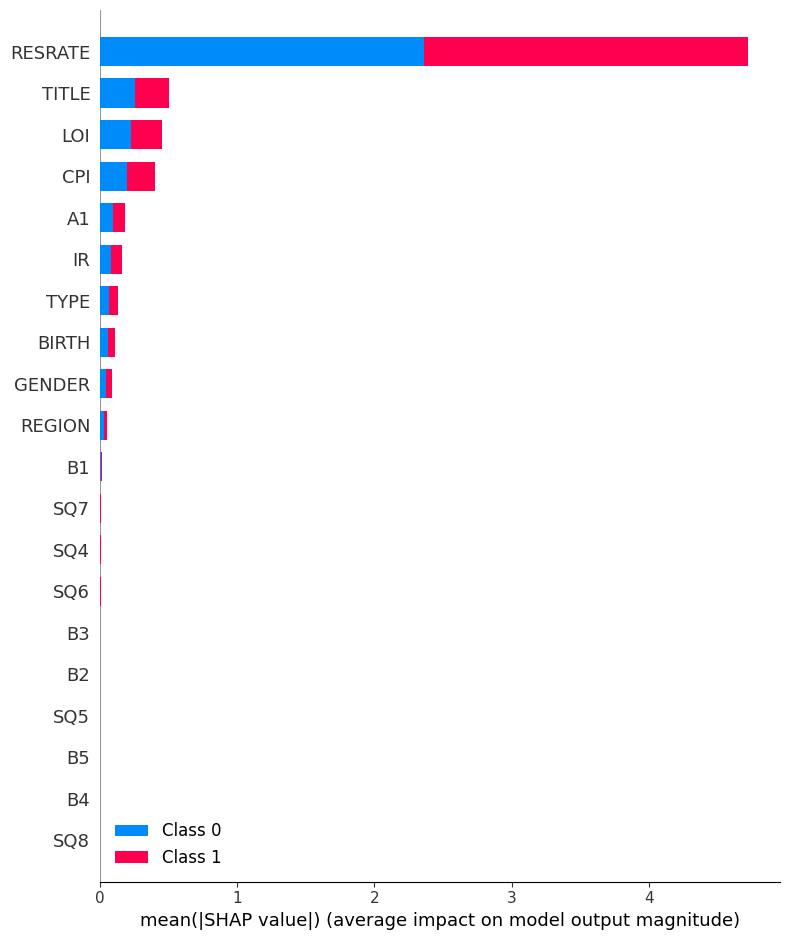

,column_name,shap_importance
19,RESRATE,2.359186
15,TITLE,0.252858
17,LOI,0.225107
18,CPI,0.199228
9,A1,0.092944
16,IR,0.078753
3,TYPE,0.063851
0,BIRTH,0.055564
1,GENDER,0.045257
2,REGION,0.027329


In [38]:
#
# Method: Using SHAP values 
#

# DF, based on which importance is checked
X_importance = X_test

# # Explain model predictions using shap library:
#LGBM쓰면 빨리 돌려지니까 이걸로 피처 추가하는 거겠지
model = LGBMClassifier(random_state=0).fit(X_train, y_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_importance)

# Plot summary_plot as barplot:
shap.summary_plot(shap_values, X_importance, plot_type='bar') #shap_values피처 중요도 

shap_sum = np.abs(shap_values).mean(axis=1)[1,:]
importance_df = pd.DataFrame([X_importance.columns.tolist(), shap_sum.tolist()]).T
importance_df.columns = ['column_name', 'shap_importance']
importance_df = importance_df.sort_values('shap_importance', ascending=False)
importance_df

In [39]:
# 지정된(SHAP_THRESHOLD) Shap feature 중요도 이상인 것만 선택
# 원래 20개였는데 15개됨
features_selected = importance_df.query('shap_importance > @SHAP_THRESHOLD').column_name.tolist()
X_train = X_train[features_selected]
X_test = X_test[features_selected]

print(X_train.shape)

(813650, 15)


<font color="#CC3D3D"><p>
##### Feature generation using KMeansFeaturizer

In [40]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 813650 entries, 0 to 813649
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   RESRATE  813650 non-null  float64
 1   TITLE    813650 non-null  float64
 2   LOI      813650 non-null  float64
 3   CPI      813650 non-null  float64
 4   A1       813650 non-null  int64  
 5   IR       813650 non-null  float64
 6   TYPE     813650 non-null  int64  
 7   BIRTH    813650 non-null  float64
 8   GENDER   813650 non-null  int64  
 9   REGION   813650 non-null  int64  
 10  B1       813650 non-null  int64  
 11  SQ7      813650 non-null  int64  
 12  SQ4      813650 non-null  int64  
 13  SQ6      813650 non-null  int64  
 14  B3       813650 non-null  int64  
dtypes: float64(6), int64(9)
memory usage: 93.1 MB


In [41]:
'''
#KMeansFeaturizer: k-means 군집분석을 실행하여 각 데이터 포인트에 가장 가까운 군집 ID를 새로운 feature로 반환  
   
from featurizer import KMeansFeaturizer  # featurizer_module은 실제 모듈 이름이다.

 #KMeansFeaturizer 클래스를 사용하는 코드
#이하 코드에서 featurizer 객체 사용

kmf_hint = KMeansFeaturizer(k=10, target_scale=5, one_hot=False, random_state=0).fit(X_train)

train_cluster_features = kmf_hint.transform(X_train)
test_cluster_features = kmf_hint.transform(X_test)

X_train = pd.concat([X_train, pd.Series(train_cluster_features, name='CLUSTER')], axis=1)
X_test = pd.concat([X_test, pd.Series(test_cluster_features, name='CLUSTER')], axis=1)'''

"\n#KMeansFeaturizer: k-means 군집분석을 실행하여 각 데이터 포인트에 가장 가까운 군집 ID를 새로운 feature로 반환  \n   \nfrom featurizer import KMeansFeaturizer  # featurizer_module은 실제 모듈 이름이다.\n\n #KMeansFeaturizer 클래스를 사용하는 코드\n#이하 코드에서 featurizer 객체 사용\n\nkmf_hint = KMeansFeaturizer(k=10, target_scale=5, one_hot=False, random_state=0).fit(X_train)\n\ntrain_cluster_features = kmf_hint.transform(X_train)\ntest_cluster_features = kmf_hint.transform(X_test)\n\nX_train = pd.concat([X_train, pd.Series(train_cluster_features, name='CLUSTER')], axis=1)\nX_test = pd.concat([X_test, pd.Series(test_cluster_features, name='CLUSTER')], axis=1)"

### Model building

In [42]:
print(X_train.shape)


(813650, 15)


- LGBM

In [44]:
model_lgbm = LGBMClassifier(n_estimators=2000,objective='binary', metric='binary_error', random_state=44)
lgbm_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
list_lgbm = []

threshold = 0.5 
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_lgbm.fit(tr_x, tr_y, eval_metric = 'accuracy')
    pred = model_lgbm.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_lgbm.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    lgbm_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_lgbm = (lgbm_pred / spl >= 0.5).astype(int)
print(final_predictions_lgbm)
print(f'{model_lgbm.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

0it [00:00, ?it/s]

[LightGBM] [Info] Number of positive: 253249, number of negative: 397671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389063 -> initscore=-0.451252
[LightGBM] [Info] Start training from score -0.451252
0.8583973452958888


1it [00:15, 15.04s/it]

[LightGBM] [Info] Number of positive: 253255, number of negative: 397665
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 545
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389072 -> initscore=-0.451213
[LightGBM] [Info] Start training from score -0.451213
0.8571314447243901


2it [00:30, 15.01s/it]

...

[LightGBM] [Info] Number of positive: 253073, number of negative: 397847
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 549
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.388793 -> initscore=-0.452390
[LightGBM] [Info] Start training from score -0.452390
0.8585509740060222


4it [01:00, 15.00s/it]

[LightGBM] [Info] Number of positive: 253186, number of negative: 397734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 546
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.388966 -> initscore=-0.451659
[LightGBM] [Info] Start training from score -0.451659
0.8570515577951208


5it [01:15, 15.00s/it]

[1 1 1 ... 0 0 1]
LGBMClassifier의 fold 평균 Accuracy는 0.8579143366312296


- XGB

In [45]:
from xgboost import XGBClassifier
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# 최적의 하이퍼파라미터 설정
best_params = {
    'n_estimators': 1146,
    'max_depth': 9,
    'learning_rate': 0.02534583366384355,
    'subsample': 0.85,
    'colsample_bytree': 0.9,
    'gamma': 0.03967425666846014,
    'min_child_weight': 4
}

model_xgb = XGBClassifier(**best_params, eval_metrics='error', objective='binary:logistic', random_state=0, verbose=200)
xgb_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
threshold = 0.5
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_xgb.fit(tr_x, tr_y)
    pred = model_xgb.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_xgb.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    xgb_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_xgb = (xgb_pred / spl >= 0.5).astype(int)
print(final_predictions_xgb)
print(f'{model_xgb.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

0it [00:00, ?it/s]

0.8586554415289129


1it [00:08,  8.19s/it]

0.8568180421557181


2it [00:16,  8.27s/it]

...

0.8585263934124009


4it [00:33,  8.32s/it]

0.8568118970073128


5it [00:41,  8.30s/it]

[1 1 1 ... 0 0 1]
XGBClassifier의 fold 평균 Accuracy는 0.8579118785718676


- CatBoost

In [46]:
model_cb = CatBoostClassifier(eval_metric= 'Accuracy',loss_function = "CrossEntropy", random_state=0, verbose = 200)
lgbm_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
list_lgbm = []

threshold = 0.5 
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_cb.fit(tr_x, tr_y)
    pred = model_cb.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_cb.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    lgbm_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_cb = (lgbm_pred / spl >= 0.5).astype(int)
print(final_predictions_cb)
print(f'{model_cb.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

0it [00:00, ?it/s]

0:	learn: 0.8344804	total: 88.4ms	remaining: 1m 28s
200:	learn: 0.8511538	total: 3.15s	remaining: 12.5s
400:	learn: 0.8540312	total: 6.19s	remaining: 9.25s
600:	learn: 0.8552203	total: 9.24s	remaining: 6.13s
800:	learn: 0.8560668	total: 12.3s	remaining: 3.05s
999:	learn: 0.8567858	total: 15.3s	remaining: 0us
0.8568426227493394


1it [00:15, 15.83s/it]

0:	learn: 0.8341793	total: 34.9ms	remaining: 34.9s
200:	learn: 0.8517007	total: 3.06s	remaining: 12.2s
400:	learn: 0.8540312	total: 6.1s	remaining: 9.11s
600:	learn: 0.8552741	total: 9.15s	remaining: 6.07s
800:	learn: 0.8562343	total: 12.2s	remaining: 3.04s


2it [00:31, 15.77s/it]

...

0:	learn: 0.8348507	total: 37ms	remaining: 36.9s
200:	learn: 0.8510063	total: 3.09s	remaining: 12.3s
400:	learn: 0.8536318	total: 6.15s	remaining: 9.18s
600:	learn: 0.8551281	total: 9.22s	remaining: 6.12s
800:	learn: 0.8561252	total: 12.3s	remaining: 3.06s


4it [01:03, 15.82s/it]

999:	learn: 0.8567259	total: 15.4s	remaining: 0us
0.8575062987771155
0:	learn: 0.8356157	total: 35.6ms	remaining: 35.5s
200:	learn: 0.8517606	total: 3.09s	remaining: 12.3s
400:	learn: 0.8542601	total: 6.14s	remaining: 9.17s
600:	learn: 0.8554999	total: 9.21s	remaining: 6.11s
800:	learn: 0.8563679	total: 12.3s	remaining: 3.05s
999:	learn: 0.8571545	total: 15.4s	remaining: 0us
0.8553309162416273


5it [01:19, 15.82s/it]

[1 1 1 ... 0 0 1]
CatBoostClassifier의 fold 평균 Accuracy는 0.8563288883426535


In [47]:
# 다섯 가지 모델의 예측값을 더하고 3으로 나누어 평균 계산
avg_predictions = (final_predictions_lgbm + final_predictions_xgb + final_predictions_cb) / 3

# 평균값을 기준으로 0 또는 1로 예측
threshold = 0.5  # 임계값 설정
final_predictions = np.where(avg_predictions >= threshold, 1, 0)

print(final_predictions)

[1 1 1 ... 0 0 1]


In [48]:
len(final_predictions)

541867

In [49]:
t = pd.Timestamp.now()
fname = f"oof_hardvoting3_{t.month:02}{t.day:02}{t.hour:02}{t.minute:02}.csv"
pd.DataFrame({'ID': ID_test, 'STATUS': final_predictions}).to_csv(fname, index=False)
print(f"'{fname}' is ready to submit.")

'oof_hardvoting3_12190247.csv' is ready to submit.


In [50]:
X_test.shape[0]

541867

In [51]:
final_predictions.shape[0]

541867

##### Make a submission

<font color="#CC3D3D"><p>
# End